In [37]:
# Import library first.
import pandas as pd

# Read file that already uploaded to Colab first
df = pd.read_csv("ABNB_NYC_2019.csv")

# Check data first.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [38]:
# Let's start cleaning data.

# Check that which column have the most missing values.
print(df.isnull().sum().sort_values(ascending = False))

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [39]:
# As from last result, it's have 4 columns that have missing values. Let's clean!

# Cleanning reviews per month column.
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# Cleaning name and host name columns.
df["name"] = df['name'].fillna("Untitled")
df["host_name"] = df["host_name"].fillna("Unknown")

# Cleaning last review column (for this column, i've only change datatype. For missing values i still left as NaT for more accurary).
df["last_review"] = pd.to_datetime(df["last_review"])

# After cleaned, check data again.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48895 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48895 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [40]:
# Check for duplicated values.

print(df.duplicated().sum())

0


In [41]:
# Check for outliers
df.describe()

# After i've check the data, I think that i've found 3 problems

# Problem number 1 & 2 is in price column -> 1. Min is 0$, and that is possible. -> 2.Max is go to 10,000$ but mean is only 152$, and Median is only 106$. So i think that it's might have something goes wrong.
# Problem number 3 is in minimum_nights column. Max goes to 1250, it's mean that i have to make reservations for 1250 night. I think that's too much.

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.090910,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.597283,32.952519,131.622289


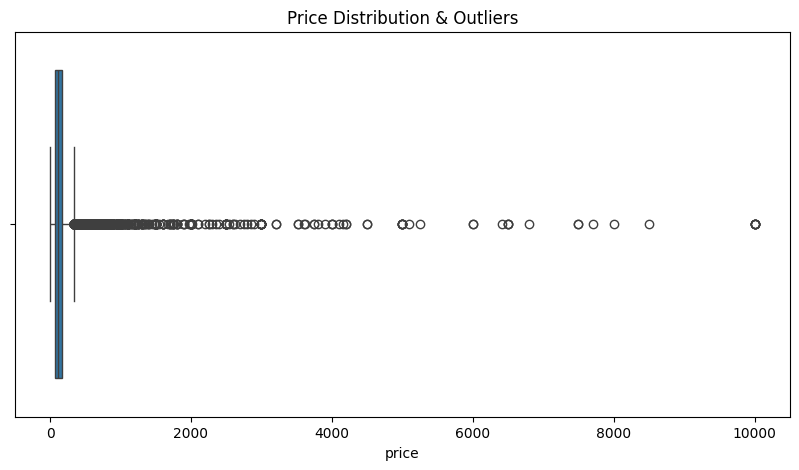

In [42]:
# I want to see clearly outliers in price column, so i will plot chart to see it.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 5))
sns.boxplot(x = df["price"])
plt.title("Price Distribution & Outliers")
plt.show()

In [43]:
df["price"].describe()

# After i've use boxplot & .describe() for check outliers in price column, I think we have something to fix.

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [44]:
# Let's fix outliers!

# Column price (Min 0$ & Max 10,000$)
# Delete row that price show 0$ because i think that is a error.
df = df[df["price"] > 0]

# Sort price only not more than 1,000$ because i want to see only market price (not too far from average)
df_clean = df[(df["price"] <= 1000) & (df["price"] > 0)]

# For minimun nights i sort only not more than 30 night(I think one month is make sense).
df_clean = df_clean[df_clean["minimum_nights"] <= 30]

df_clean[ ["price", "minimum_nights"] ].describe()

,price,minimum_nights
count,47924.000000,47924.000000
mean,141.314832,5.576016
std,116.865661,8.195583
min,10.000000,1.000000
25%,69.000000,1.000000
50%,105.000000,2.000000
75%,175.000000,5.000000
max,1000.000000,30.000000


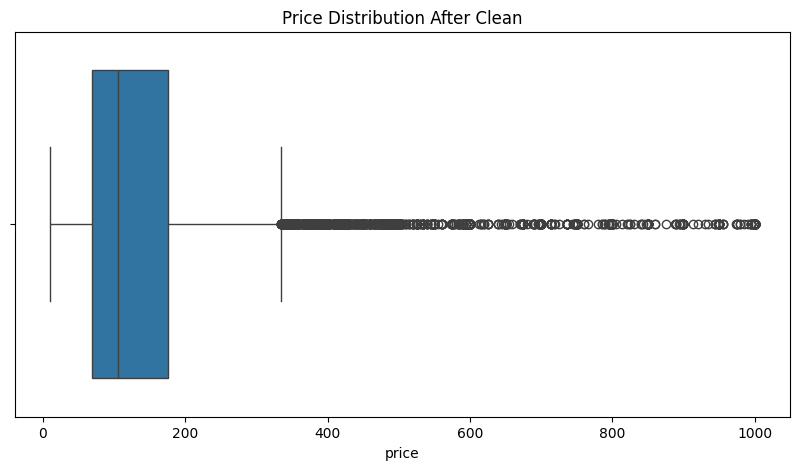

In [45]:
# Check price column with boxplot again

plt.figure(figsize = (10, 5))
sns.boxplot(x = df_clean["price"])
plt.title("Price Distribution After Clean")
plt.show()

In [46]:
# After cleaned numeric data, now let's check text data.

print(df_clean["neighbourhood_group"].unique())

print(df_clean["room_type"].unique())

# Text data already cleaned.

['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']
['Private room' 'Entire home/apt' 'Shared room']


In [50]:
# After do data cleaning, I've have curious about how much is an average price for each neighbourgood group.
# Let's find some insight!

avg_price_by_area = df_clean.groupby("neighbourhood_group")["price"].mean().sort_values(ascending = False).reset_index()
print("Average price based on neighbourhood group.")
print(avg_price_by_area)

Average price based on neighbourhood group.
  neighbourhood_group       price
0           Manhattan  179.170106
1            Brooklyn  117.871691
2       Staten Island   98.950954
3              Queens   95.203248
4               Bronx   85.562268


/tmp/ipykernel_2694/1054930474.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = avg_price_by_area, x = "neighbourhood_group", y = "price", palette = "magma")


Text(0, 0.5, 'Average price')

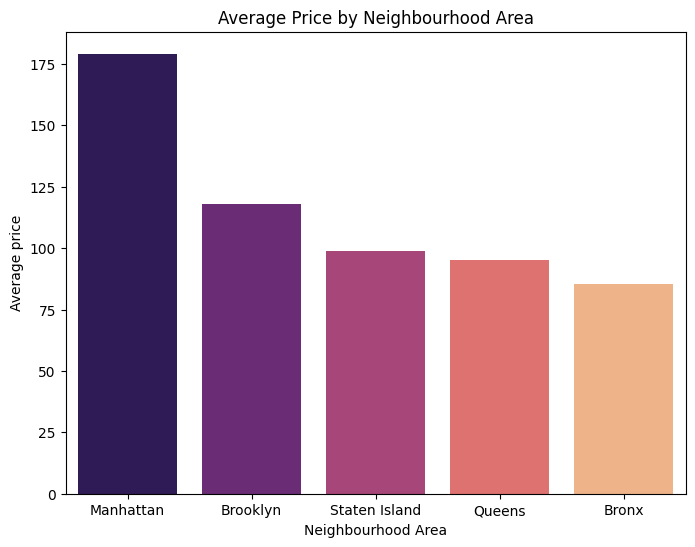

In [54]:
# Let's see our insight in one chart.

plt.figure(figsize = (8, 6))
sns.barplot(data = avg_price_by_area, x = "neighbourhood_group", y = "price", palette = "magma")
plt.title("Average Price by Neighbourhood Area")
plt.xlabel("Neighbourhood Area")
plt.ylabel("Average price")